## IMPORTING THE LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## IMPORTING DATASET

In [2]:
df = pd.read_csv('hearts.csv')
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


## DATA PREPROCESSING

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [5]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

[Text(0, 0, '508')]

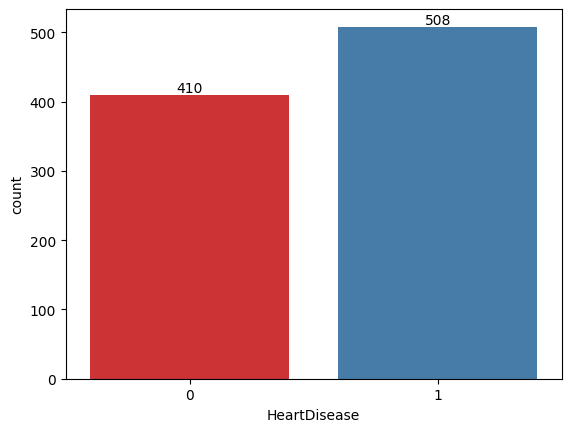

In [6]:
ax = sns.countplot(x=df["HeartDisease"], palette="Set1")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

Text(0.5, 1.0, 'Distribution Of Age')

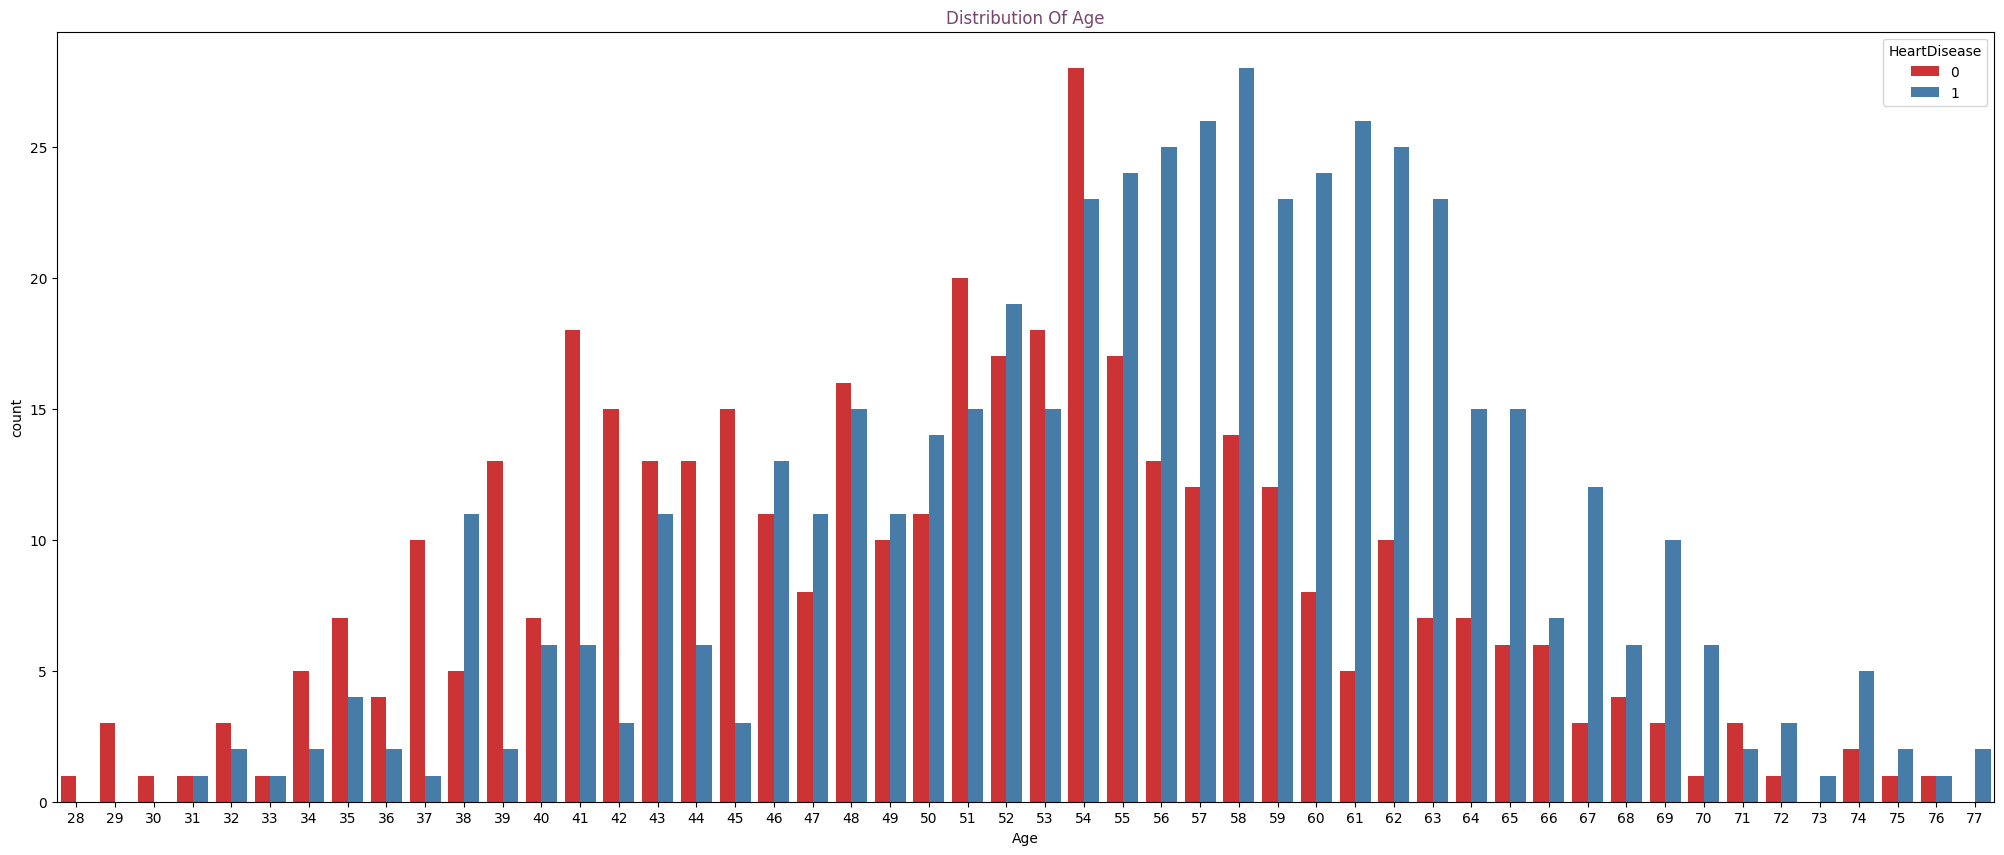

In [7]:
plt.figure(figsize=(25, 10))
Days_of_week = sns.countplot(
    x=df["Age"], data=df, hue="HeartDisease", palette="Set1"
)
Days_of_week.set_title("Distribution Of Age", color="#774571")

In [8]:
df_encoded = pd.get_dummies(df, columns=['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'])

<Axes: >

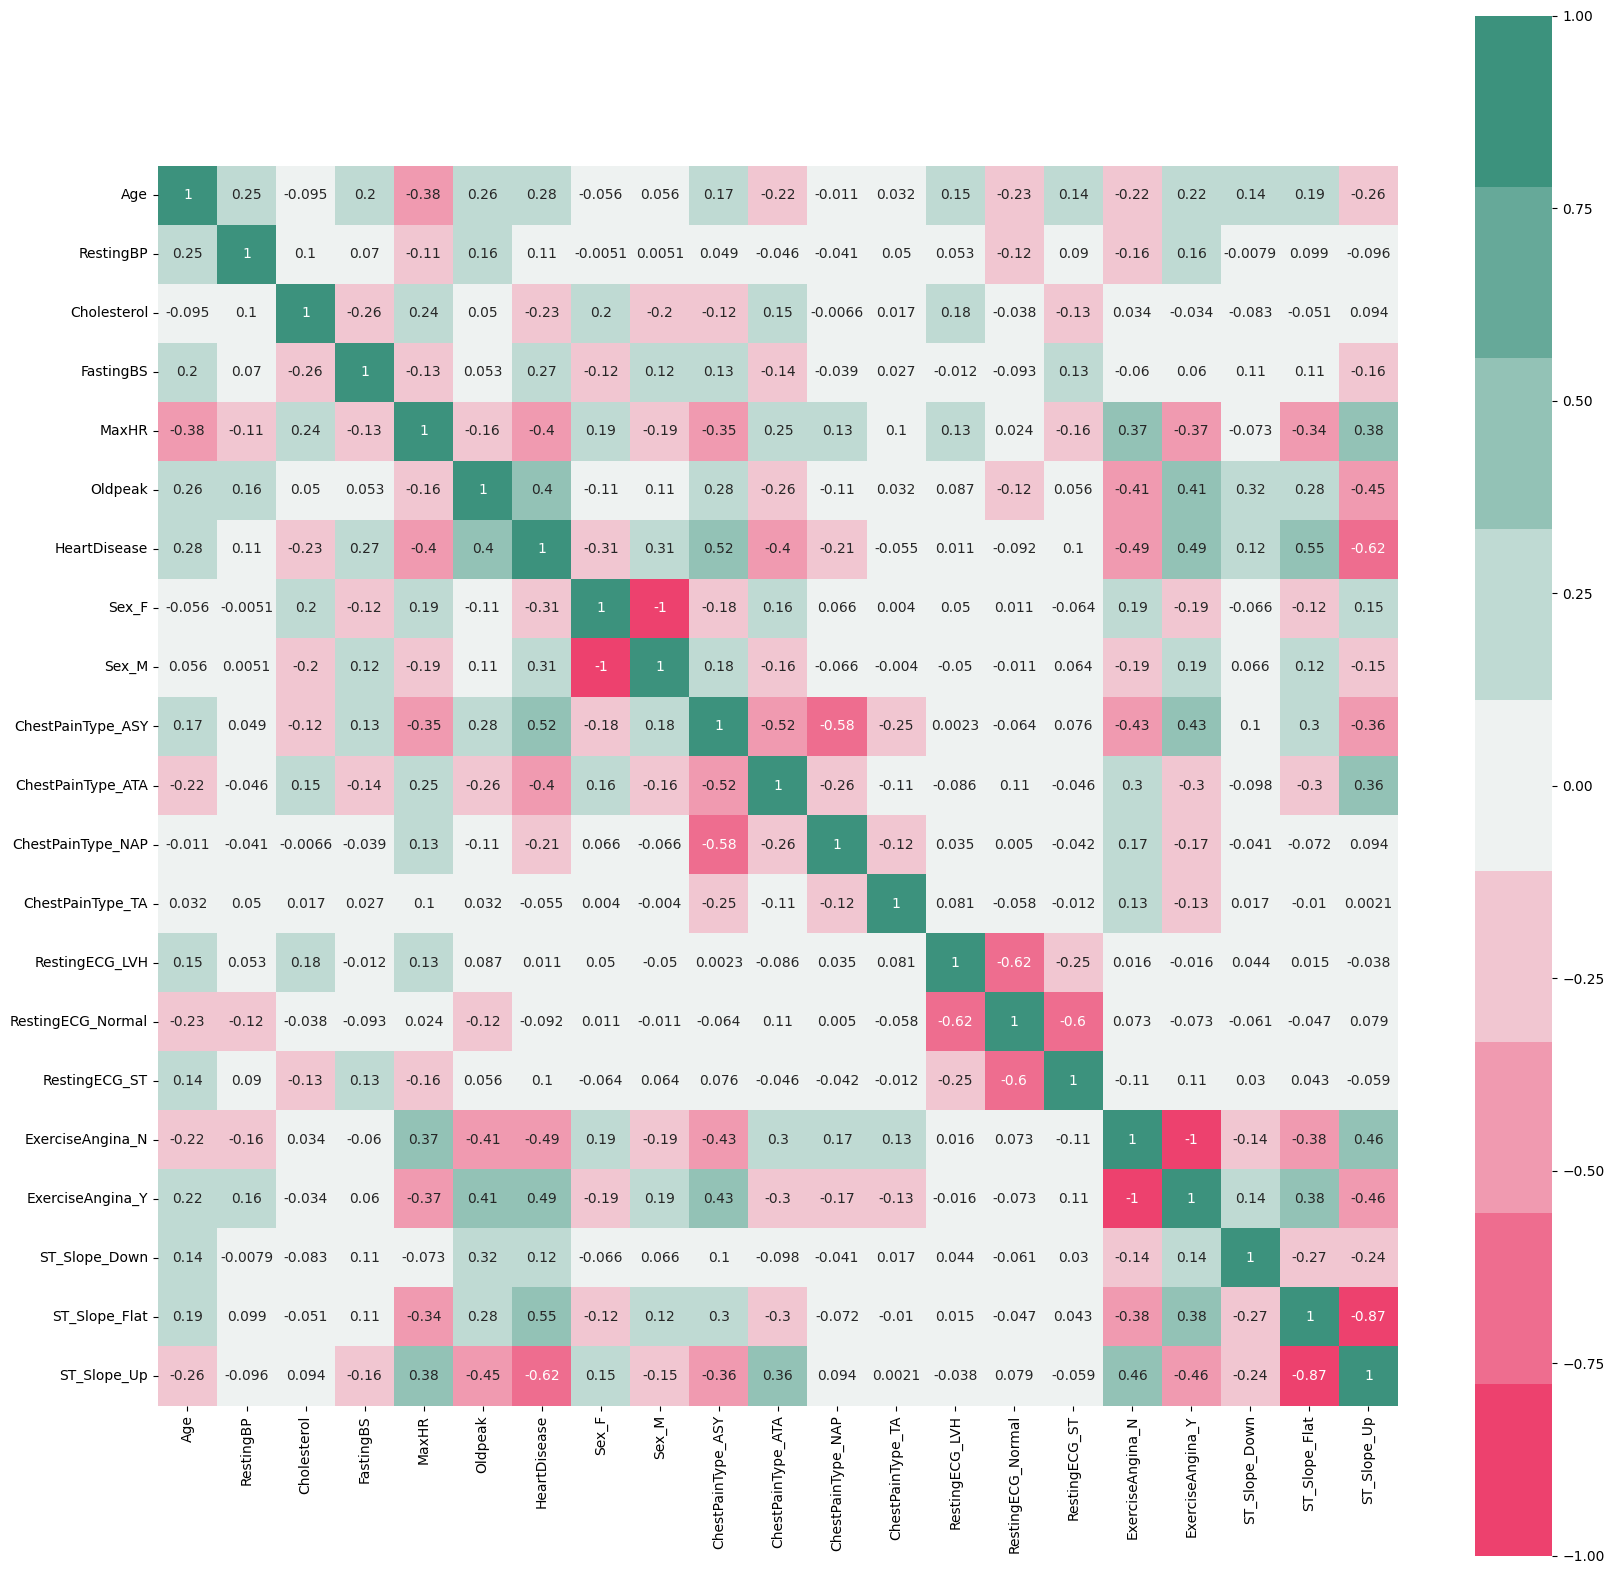

In [9]:
# Doing Bivariate Analysis by examaning a corelation matrix of all the features using heatmap
cmap = sns.diverging_palette(2, 165, s=80, l=55, n=9)
corrmat = df_encoded.corr()
plt.subplots(figsize=(20, 20))
sns.heatmap(corrmat, cmap=cmap, annot=True, square=True)

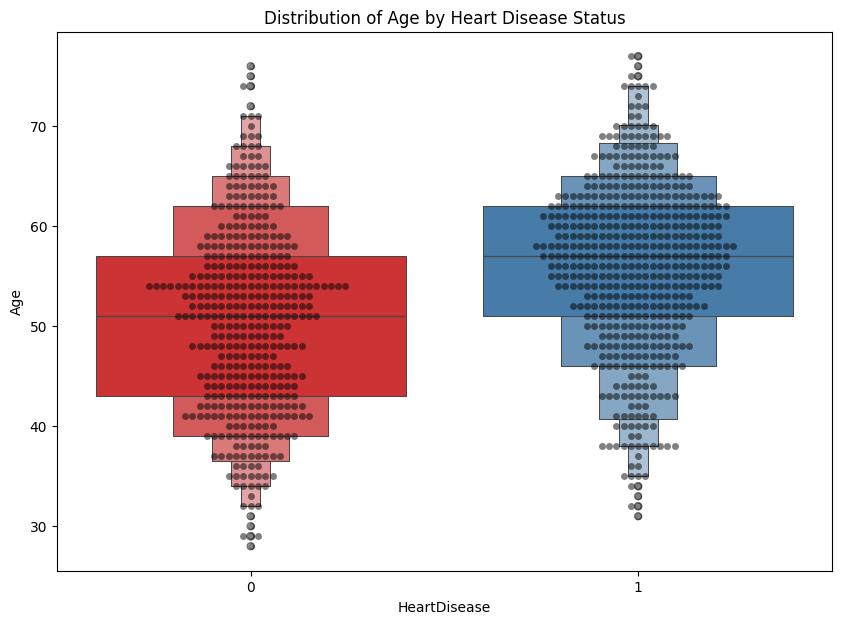

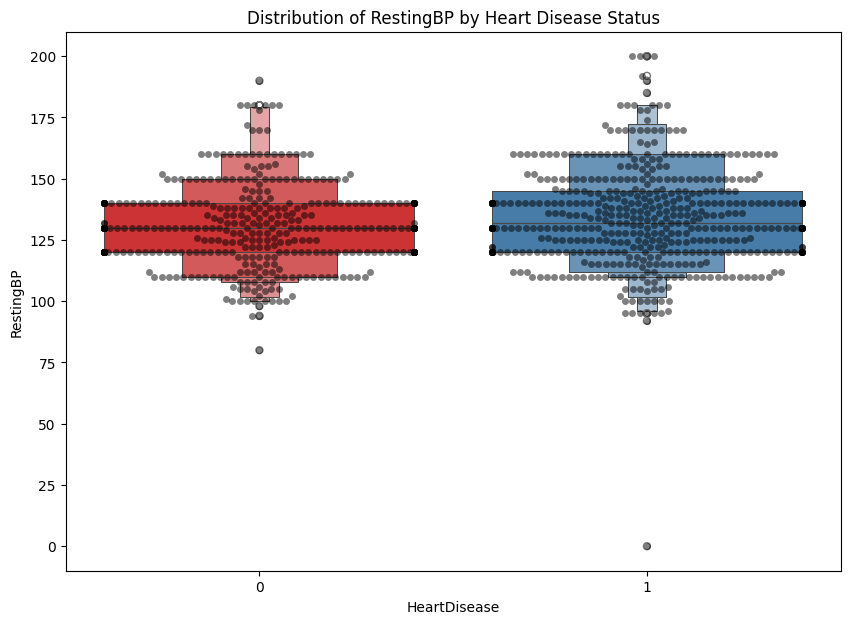

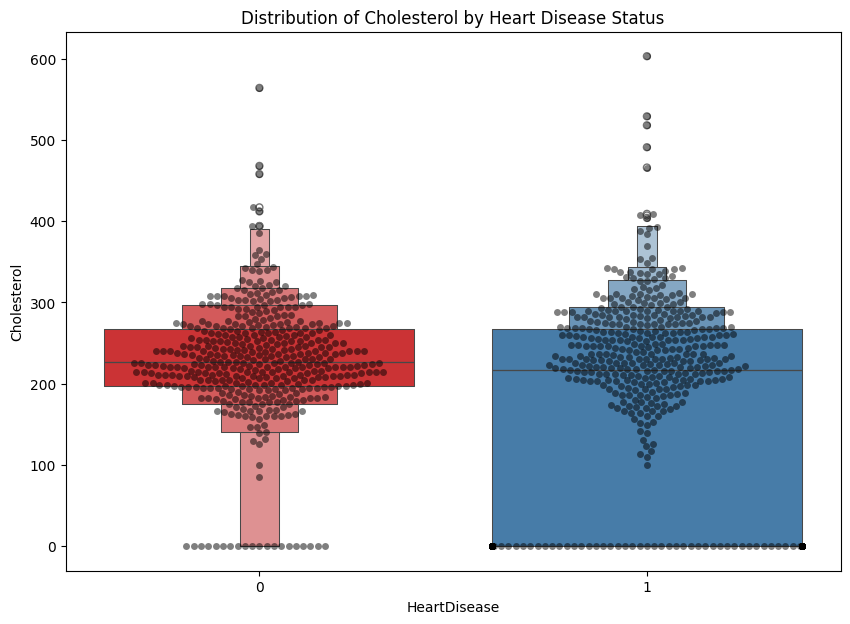

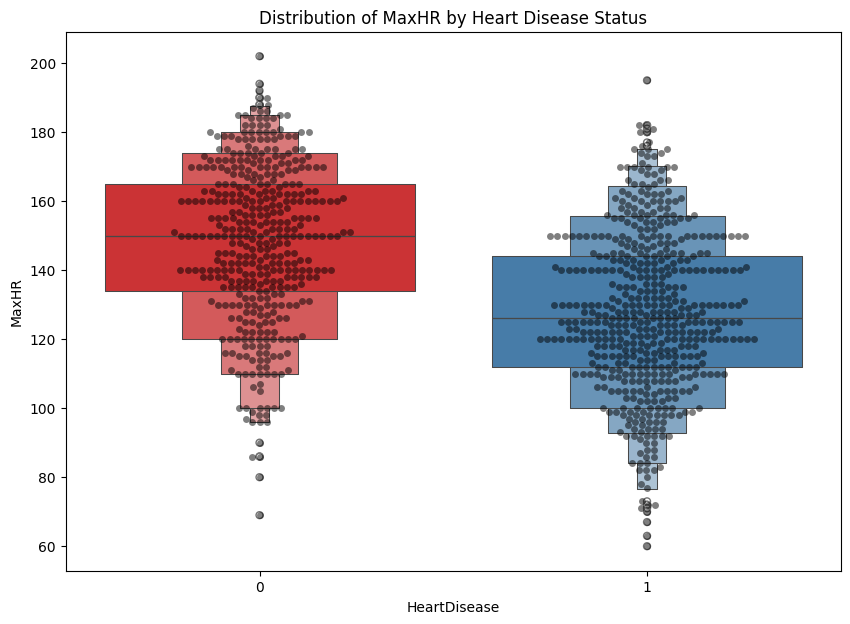

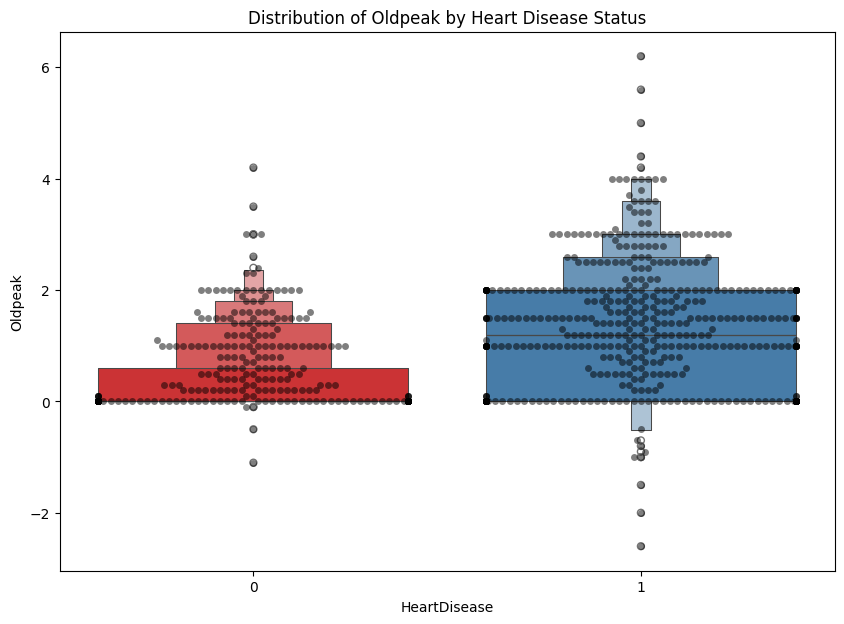

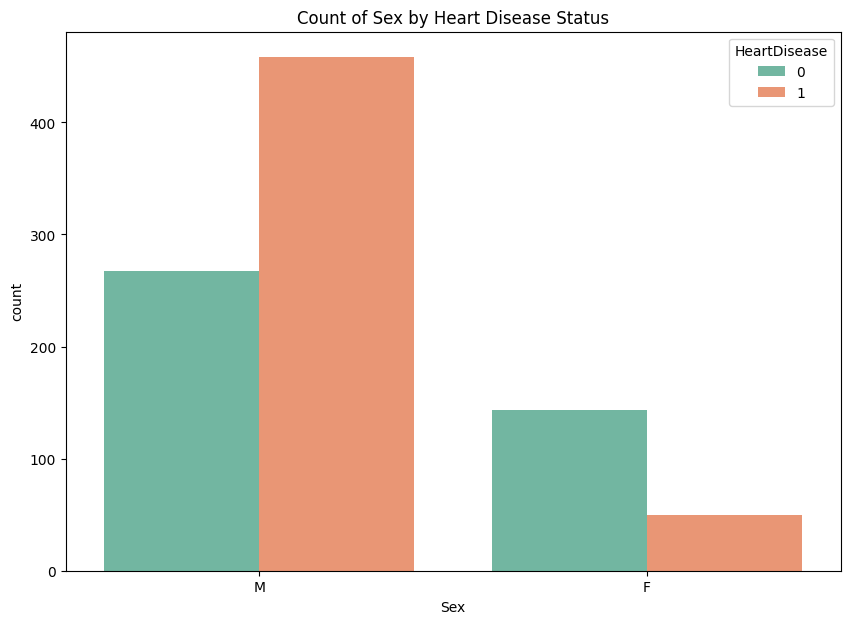

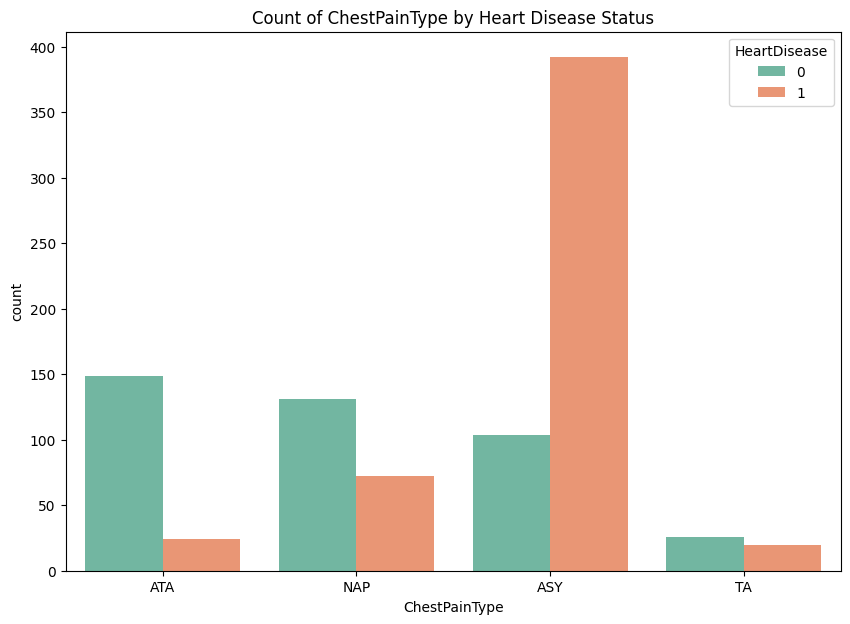

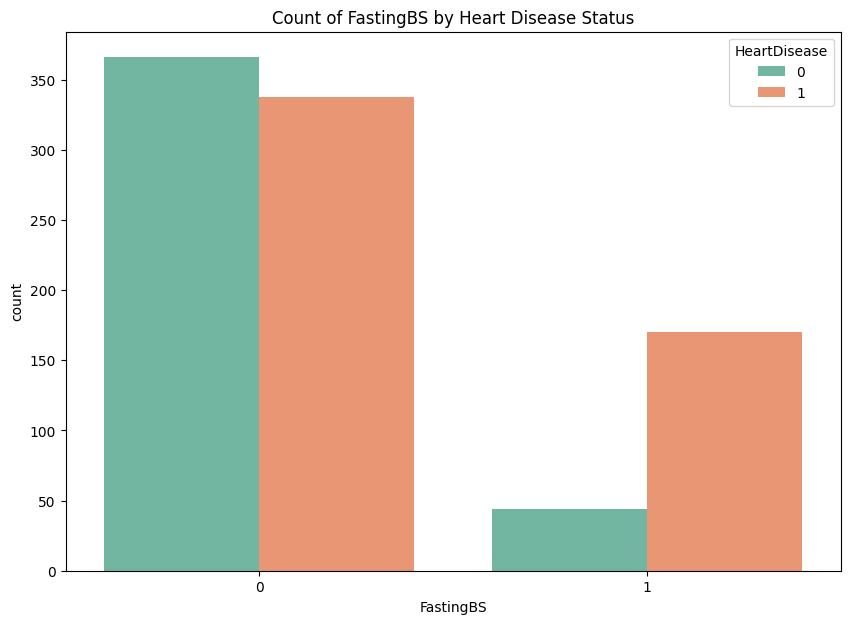

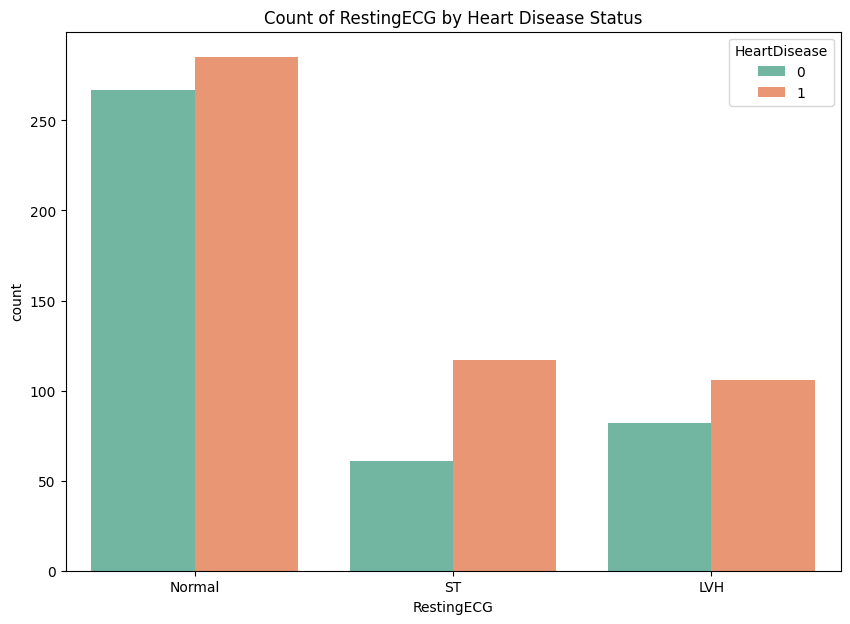

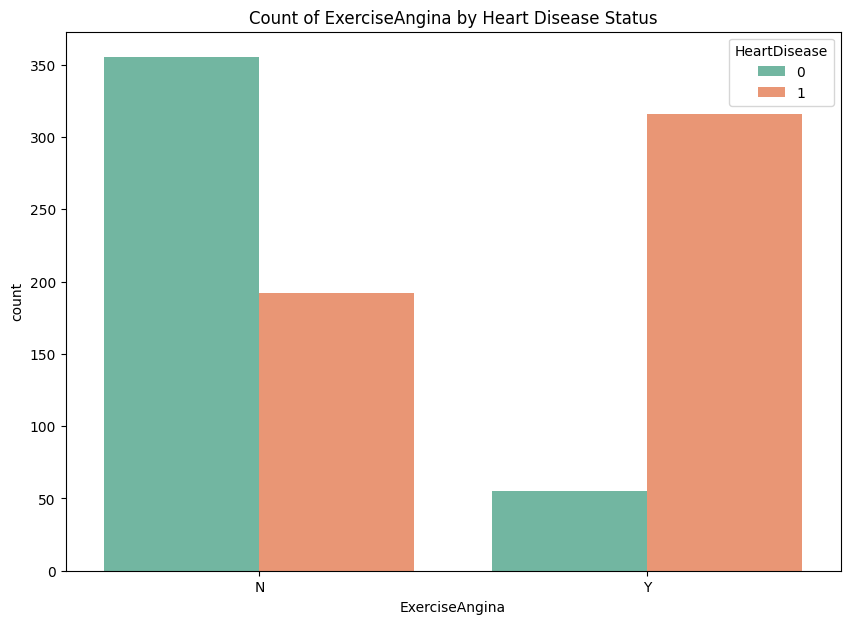

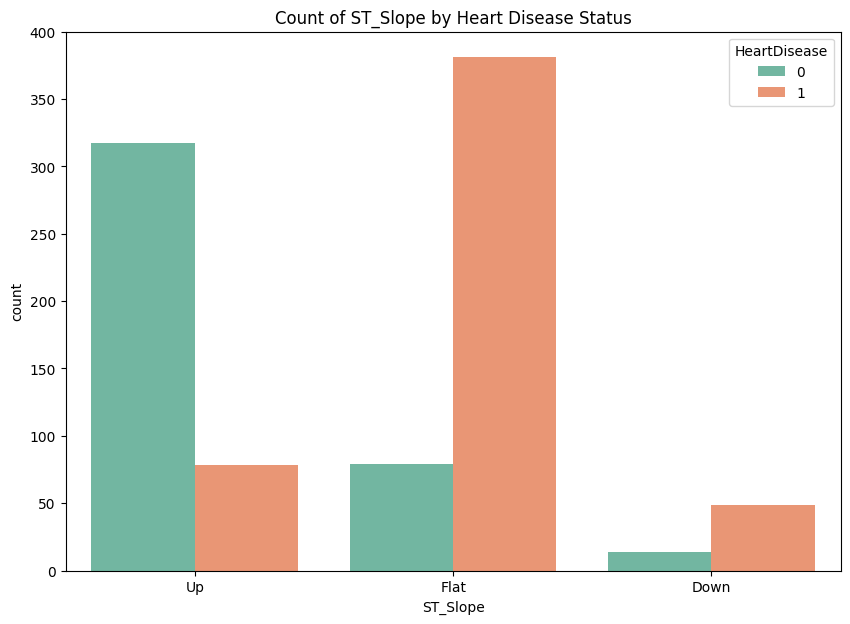

In [10]:
numerical_features = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
categorical_features = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope"]

for i in numerical_features:
    plt.figure(figsize=(10, 7))
    # Use the original 'df', not 'df_encoded'
    sns.boxenplot(x=df["HeartDisease"], y=df[i], palette="Set1")
    sns.swarmplot(x=df["HeartDisease"], y=df[i], color="black", alpha=0.5)
    plt.title(f"Distribution of {i} by Heart Disease Status")
    plt.show()

# 3. PLOT CATEGORICAL FEATURES (Countplot is better here)
for i in categorical_features:
    plt.figure(figsize=(10, 7))
    sns.countplot(x=df[i], hue=df["HeartDisease"], palette="Set2")
    plt.title(f"Count of {i} by Heart Disease Status")
    plt.show()

## MODEL BUILDING

In [11]:
X=df.drop(columns=['HeartDisease'])   
y=df['HeartDisease']      

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [1,2,6,8,10])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

In [13]:
print(X)

[[  0.    1.    0.  ...   0.  172.    0. ]
 [  1.    0.    0.  ...   0.  156.    1. ]
 [  0.    1.    0.  ...   0.   98.    0. ]
 ...
 [  0.    1.    1.  ...   0.  115.    1.2]
 [  1.    0.    0.  ...   0.  174.    0. ]
 [  0.    1.    0.  ...   0.  173.    0. ]]


In [14]:
print(y)

0      0
1      1
2      0
3      1
4      0
      ..
913    1
914    1
915    1
916    1
917    0
Name: HeartDisease, Length: 918, dtype: int64


In [15]:
# Get the new column names
column_names = ct.get_feature_names_out()

for i, name in enumerate(column_names):
    print(f"{i}: {name}")

0: encoder__Sex_F
1: encoder__Sex_M
2: encoder__ChestPainType_ASY
3: encoder__ChestPainType_ATA
4: encoder__ChestPainType_NAP
5: encoder__ChestPainType_TA
6: encoder__RestingECG_LVH
7: encoder__RestingECG_Normal
8: encoder__RestingECG_ST
9: encoder__ExerciseAngina_N
10: encoder__ExerciseAngina_Y
11: encoder__ST_Slope_Down
12: encoder__ST_Slope_Flat
13: encoder__ST_Slope_Up
14: remainder__Age
15: remainder__RestingBP
16: remainder__Cholesterol
17: remainder__FastingBS
18: remainder__MaxHR
19: remainder__Oldpeak


In [18]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

col_names = ct.get_feature_names_out()
s_scaler = StandardScaler()
X_scaled = s_scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=col_names)
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
encoder__Sex_F,918.0,-7.740117e-18,1.000545,-0.515952,-0.515952,-0.515952,-0.515952,1.938163
encoder__Sex_M,918.0,7.740117e-18,1.000545,-1.938163,0.515952,0.515952,0.515952,0.515952
encoder__ChestPainType_ASY,918.0,-1.548023e-16,1.000545,-1.084138,-1.084138,0.922392,0.922392,0.922392
encoder__ChestPainType_ATA,918.0,-9.288140e-17,1.000545,-0.481887,-0.481887,-0.481887,-0.481887,2.075177
encoder__ChestPainType_NAP,918.0,6.192094e-17,1.000545,-0.532838,-0.532838,-0.532838,-0.532838,1.876744
encoder__ChestPainType_TA,918.0,7.740117e-18,1.000545,-0.229679,-0.229679,-0.229679,-0.229679,4.353909
encoder__RestingECG_LVH,918.0,1.238419e-16,1.000545,-0.507478,-0.507478,-0.507478,-0.507478,1.970528
encoder__RestingECG_Normal,918.0,9.288140e-17,1.000545,-1.228087,-1.228087,0.814275,0.814275,0.814275
encoder__RestingECG_ST,918.0,0.000000e+00,1.000545,-0.490449,-0.490449,-0.490449,-0.490449,2.038947
encoder__ExerciseAngina_N,918.0,7.740117e-17,1.000545,-1.214246,-1.214246,0.823556,0.823556,0.823556


In [19]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.3,random_state=12) 

print("DF",df.shape)
print("x_train",x_train.shape)
print("x_test",x_test.shape)
print("y_train",y_train.shape)
print("y_test",y_test.shape)

DF (918, 12)
x_train (642, 20)
x_test (276, 20)
y_train (642,)
y_test (276,)


## 1. Support Vector Machine

In [20]:
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

In [21]:
print("Evaluation for Support Vector Machine".center(75, "_"))

svm_model = svm.SVC(kernel="linear")
svm_model.fit(x_train, y_train)

svm_pred = svm_model.predict(x_test)
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred)
svm_recall = recall_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred)

print("Prediciton:    ", svm_pred)
print("_" * 75)

print("Accuracy:" + "\t" + f"{( svm_accuracy * 100)}%")
print("Precision:" + "\t" + f"{(svm_precision * 100)}%")
print("Recall:" + "\t\t" f"{(svm_recall * 100)}%")
print("F1-Score:" + "\t" + f"{(svm_f1 * 100)}%")
print("_" * 75)

___________________Evaluation for Support Vector Machine___________________
Prediciton:     [1 0 1 1 1 0 1 1 0 1 1 0 1 1 1 0 0 0 0 1 1 0 0 1 1 1 0 1 1 1 0 1 1 0 1 0 1
 0 0 0 1 1 1 0 1 0 1 1 1 0 1 1 1 0 0 1 0 1 0 0 0 1 1 0 0 1 1 1 0 0 0 1 0 0
 0 1 1 0 0 0 1 1 0 1 1 0 1 1 1 1 0 1 0 0 1 1 0 0 1 0 1 1 0 0 0 1 1 1 0 1 0
 0 1 1 0 1 0 1 0 0 1 1 1 0 1 1 1 0 1 1 0 1 0 1 1 1 0 1 1 1 0 1 1 1 0 0 0 0
 1 0 0 0 1 1 1 0 1 0 1 0 0 0 0 1 0 0 1 0 0 1 1 1 0 1 0 1 1 1 0 0 0 0 1 0 0
 0 0 0 0 1 1 1 1 0 1 1 0 1 1 1 0 0 0 0 1 0 1 1 0 1 1 0 0 0 0 1 1 1 0 0 1 1
 1 0 1 1 1 0 1 0 1 1 1 1 1 0 1 0 1 1 0 1 1 1 0 1 0 1 0 0 0 1 0 1 1 1 1 0 1
 1 0 0 1 1 1 0 1 1 1 0 1 1 0 0 0 0]
___________________________________________________________________________
Accuracy:	85.86956521739131%
Precision:	87.41721854304636%
Recall:		86.8421052631579%
F1-Score:	87.12871287128714%
___________________________________________________________________________


In [22]:
print("Confusion Matrix For Support Vector Machine - 'Labels Test' & 'Prediction':")
print("-" * 93)
print(confusion_matrix(y_test, svm_pred))

Confusion Matrix For Support Vector Machine - 'Labels Test' & 'Prediction':
---------------------------------------------------------------------------------------------
[[105  19]
 [ 20 132]]


In [23]:
print(
    "Classification Report For Support Vector Machine - 'Labels Test' & 'Prediction':"
)
print("-" * 97)
print(classification_report(y_test, svm_pred))

Classification Report For Support Vector Machine - 'Labels Test' & 'Prediction':
-------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.84      0.85      0.84       124
           1       0.87      0.87      0.87       152

    accuracy                           0.86       276
   macro avg       0.86      0.86      0.86       276
weighted avg       0.86      0.86      0.86       276



## 2. KNeighborsClassifier

In [24]:
print("Evaluation for K-Nearest Neighbors".center(75, "_"))

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train, y_train)

knn_pred = knn_model.predict(x_test)
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred)
knn_recall = recall_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)

print("Prediciton:    ", knn_pred)
print("_" * 75)

print("Accuracy:" + "\t" + f"{(knn_accuracy * 100)}%")
print("Precision:" + "\t" + f"{(knn_precision * 100)}%")
print("Recall:" + "\t\t" f"{(knn_recall * 100)}%")
print("F1-Score:" + "\t" + f"{(knn_f1 * 100)}%")
print("_" * 75)

_____________________Evaluation for K-Nearest Neighbors____________________
Prediciton:     [0 0 1 1 1 0 1 1 0 1 0 0 1 0 1 0 0 1 0 1 1 0 0 1 1 1 0 1 1 1 0 1 1 0 1 0 0
 1 0 0 1 1 1 0 1 0 1 0 1 0 1 1 1 0 0 0 0 1 0 0 1 1 1 0 0 0 1 1 0 0 0 1 0 0
 0 1 1 0 0 0 1 1 0 0 0 0 1 1 1 1 0 1 1 0 1 1 0 0 1 0 1 1 0 0 0 1 0 1 0 1 0
 0 1 1 0 1 0 1 0 0 1 1 1 0 1 1 1 0 1 1 0 1 0 1 1 1 0 1 1 1 0 1 1 1 0 0 0 0
 1 0 0 0 1 1 1 1 1 0 1 0 1 0 0 1 0 0 1 0 0 1 1 1 0 1 0 0 1 1 0 0 0 0 1 0 0
 0 0 0 0 1 1 0 1 0 1 1 0 1 1 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 1 1 1 0 0 1 1
 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 0 1 0 1 1 0 0 0 0 1 1 1 1 1 1
 1 0 1 1 1 1 0 1 1 1 0 1 1 0 0 0 0]
___________________________________________________________________________
Accuracy:	84.78260869565217%
Precision:	87.16216216216216%
Recall:		84.86842105263158%
F1-Score:	86.0%
___________________________________________________________________________


In [25]:
print("Confusion Matrix For K-Nearest Neighbors - 'Labels Test' & 'Prediction':")
print("-" * 93)
print(confusion_matrix(y_test, knn_pred))

Confusion Matrix For K-Nearest Neighbors - 'Labels Test' & 'Prediction':
---------------------------------------------------------------------------------------------
[[105  19]
 [ 23 129]]


In [26]:
print("Classification Report For K-Nearest Neighbors - 'Labels Test' & 'Prediction':")
print("-" * 97)
print(classification_report(y_test, knn_pred))

Classification Report For K-Nearest Neighbors - 'Labels Test' & 'Prediction':
-------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       124
           1       0.87      0.85      0.86       152

    accuracy                           0.85       276
   macro avg       0.85      0.85      0.85       276
weighted avg       0.85      0.85      0.85       276



## 3. Logistic Regression

In [27]:
print("Evaluation for Logistic Regression".center(75, "_"))

log_model = LogisticRegression()
log_model.fit(x_train, y_train)

log_pred = log_model.predict(x_test)
log_accuracy = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)

print("Prediciton:    ", log_pred)
print("_" * 75)

print("Accuracy:" + "\t" + f"{(log_accuracy * 100)}%")
print("Precision:" + "\t" + f"{(log_precision * 100)}%")
print("Recall:" + "\t\t" f"{(log_recall * 100)}%")
print("F1-Score:" + "\t" + f"{(log_f1 * 100)}%")
print("_" * 75)

_____________________Evaluation for Logistic Regression____________________
Prediciton:     [1 0 1 1 1 0 1 1 0 1 1 0 1 1 1 0 0 0 0 1 1 0 0 1 1 1 0 1 1 1 0 1 1 0 1 0 1
 0 0 0 1 1 1 0 1 0 1 1 1 0 1 1 1 0 0 1 0 1 0 0 0 1 1 0 0 1 1 1 0 0 0 1 0 0
 0 1 1 0 0 0 1 1 0 1 1 0 1 1 1 1 0 1 0 0 1 1 0 0 1 0 1 1 0 0 0 1 1 1 0 1 0
 1 1 1 0 1 0 1 0 0 1 1 1 0 1 1 1 0 1 1 0 1 0 1 1 1 0 1 1 1 0 1 1 1 0 0 0 0
 1 0 0 0 1 1 1 0 1 0 1 0 0 0 0 1 0 0 1 0 0 1 1 1 0 1 0 1 1 1 0 0 0 0 1 0 0
 0 0 0 0 1 1 1 1 0 1 1 0 1 1 1 0 0 0 0 1 0 1 1 0 1 1 0 0 0 0 1 1 1 0 0 1 1
 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 1 0 1 1 1 0 1 0 1 0 0 0 1 0 1 1 1 1 1 1
 1 0 0 1 1 1 0 0 1 1 0 1 1 0 0 0 0]
___________________________________________________________________________
Accuracy:	85.14492753623189%
Precision:	86.27450980392157%
Recall:		86.8421052631579%
F1-Score:	86.55737704918033%
___________________________________________________________________________


In [28]:
print("Confusion Matrix For Logistic Regression - 'Labels Test' & 'Prediction':")
print("-" * 93)
print(confusion_matrix(y_test, log_pred))

Confusion Matrix For Logistic Regression - 'Labels Test' & 'Prediction':
---------------------------------------------------------------------------------------------
[[103  21]
 [ 20 132]]


In [29]:
print("Classification Report For Logistic Regression - 'Labels Test' & 'Prediction':")
print("-" * 97)
print(classification_report(y_test, log_pred))

Classification Report For Logistic Regression - 'Labels Test' & 'Prediction':
-------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.84      0.83      0.83       124
           1       0.86      0.87      0.87       152

    accuracy                           0.85       276
   macro avg       0.85      0.85      0.85       276
weighted avg       0.85      0.85      0.85       276



## Comparison

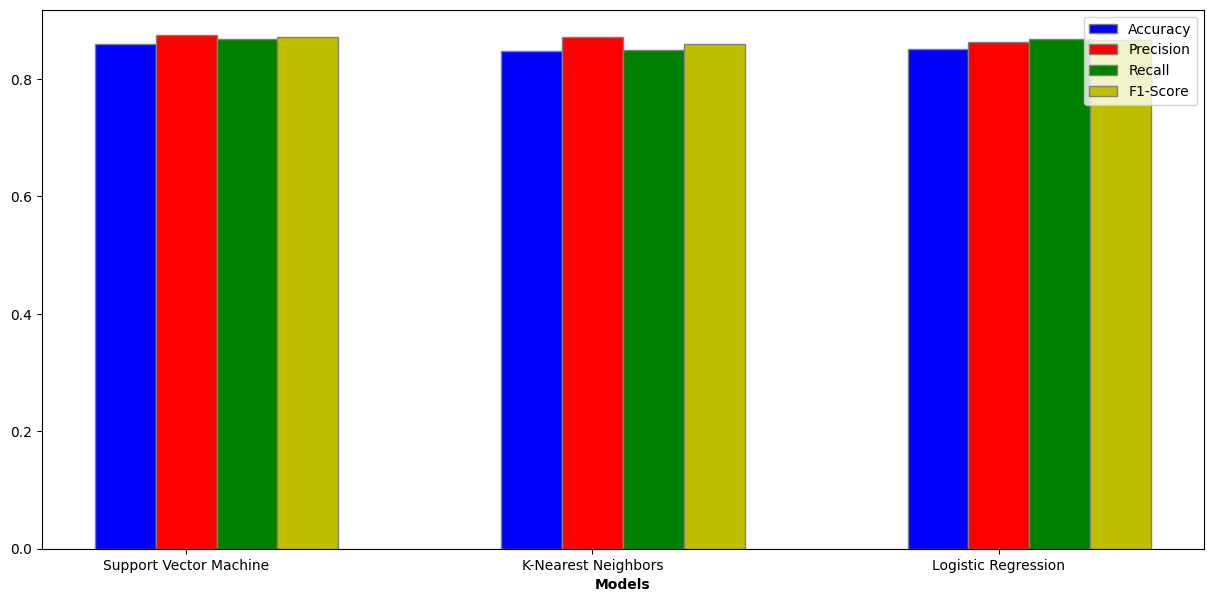

In [30]:
models = ["Support Vector Machine", "K-Nearest Neighbors", "Logistic Regression"]
accuracy = [svm_accuracy, knn_accuracy, log_accuracy]
precision = [svm_precision, knn_precision, log_precision]
recall = [svm_recall, knn_recall, log_recall]
f1 = [svm_f1, knn_f1, log_f1]

barWidth = 0.15

r1 = np.arange(len(accuracy))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]
r4 = [x + barWidth for x in r3]

plt.figure(figsize=(15, 7))

plt.bar(r1, accuracy, color="b", width=barWidth, edgecolor="grey", label="Accuracy")
plt.bar(r2, precision, color="r", width=barWidth, edgecolor="grey", label="Precision")
plt.bar(r3, recall, color="g", width=barWidth, edgecolor="grey", label="Recall")
plt.bar(r4, f1, color="y", width=barWidth, edgecolor="grey", label="F1-Score")

plt.xlabel("Models", fontweight="bold")
plt.xticks([r + barWidth for r in range(len(accuracy))], models)

plt.legend()
plt.show()

## Predictions

In [31]:
new_patient = [[50, 'M', 'ASY', 140, 250, 0, 'Normal', 150, 'N', 1.5, 'Flat']]

new_patient_df = pd.DataFrame(new_patient, columns=[
    'Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 
    'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope'
])

In [32]:
new_patient_encoded = ct.transform(new_patient_df)
new_patient_scaled = s_scaler.transform(new_patient_encoded)

In [33]:
prediction = svm_model.predict(new_patient_scaled)

if prediction[0] == 1:
    print("Result: High risk of Heart Disease")
else:
    print("Result: Low risk/Normal")

Result: High risk of Heart Disease


In [34]:
def predict_heart_health(patient_data_list):
    df_temp = pd.DataFrame([patient_data_list], columns=new_patient_df.columns)
    transformed = ct.transform(df_temp)
    scaled = s_scaler.transform(transformed)
    return svm_model.predict(scaled)[0]

In [35]:
print(predict_heart_health([60, 'F', 'NAP', 130, 200, 0, 'Normal', 160, 'N', 0, 'Up']))

0
